In [ ]:
import os
import sys
import torch
import numpy as np
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import ConcatDataset, DataLoader, random_split

from transformer import ViT

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [49]:
train = datasets.CIFAR100(root="./data", train=True, download=True)
test = datasets.CIFAR100(root="./data", train=False, download=True)

full_dataset = ConcatDataset([train, test])

Files already downloaded and verified
Files already downloaded and verified


In [50]:
total = len(full_dataset)
train_frac = 0.8
val_frac = 0.1

train_len = int(train_frac*total)
val_len = int(val_frac*total)
test_len = total - train_len - val_len

train_ds, val_ds, test_ds = random_split(full_dataset, [train_len, val_len, test_len])

In [51]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(),
    transforms.ToTensor(),
])

transform = transforms.ToTensor()

class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

In [52]:
train_ds = TransformDataset(train_ds, train_transform)
val_ds = TransformDataset(val_ds, transform)
test_ds = TransformDataset(test_ds, transform)

In [53]:
HIDDEN_DIM = 256
BATCH_SIZE = 256
LEARNING_RATE=3e-4
EPOCHS = 25

In [54]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [55]:
model = ViT(
    img_size=32, 
    patch_size=4, 
    embedding_dim=HIDDEN_DIM, 
    attention_heads=4,
    n_blocks=6,
    head=torch.nn.Linear(HIDDEN_DIM, 100)
).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)

/root/miniconda3/envs/vila1.5/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [56]:
model

ViT(
  (embedding): PatchEmbedding(
    (conv): LazyConv2d(0, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (blocks): ModuleList(
    (0-5): 6 x EncoderBlock(
      (multihead_attention): MultiheadAttention(
        (attention): ModuleList(
          (0-3): 4 x DotProductAttention(
            (fc_q): Linear(in_features=64, out_features=64, bias=True)
            (fc_k): Linear(in_features=64, out_features=64, bias=True)
            (fc_v): Linear(in_features=64, out_features=64, bias=True)
          )
        )
        (fc_cat): Linear(in_features=256, out_features=256, bias=True)
      )
      (feed_forward): PositionalFF(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (activation): ReLU()
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (head): Linear(in_features=256, out_featur

In [57]:
data = {
    "train acc": [],
    "train loss": [],
    "val acc": [],
    "val loss": []
}

for e in range(EPOCHS):
    print(f"Epoch {e+1}/{EPOCHS}")

    total_correct = 0
    total = 0
    model.train()

    for batch in tqdm(train_loader, desc="    Train "):
        optimizer.zero_grad()

        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        answer = torch.argmax(output, dim=-1)
        correct = (answer == labels).sum().item()
        total_correct += correct
        total += len(labels)
    print(f"    Train Accuracy = {total_correct/total} | Loss = {loss.item()}")
    data["train acc"].append(total_correct/total)
    data["train loss"].append(loss.item())

    total_correct = 0
    total = 0
    model.eval()

    for batch in tqdm(val_loader, desc="    Val   "):

        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        loss = criterion(output, labels)

        answer = torch.argmax(output, dim=-1)
        correct = (answer == labels).sum().item()
        total_correct += correct
        total += len(labels)
    print(f"    Val Accuracy   = {total_correct/total} | Loss = {loss.item()}")
    data["val acc"].append(total_correct/total)
    data["val loss"].append(loss.item())


Epoch 1/25


    Train : 100%|██████████| 188/188 [00:51<00:00,  3.65it/s]


    Train Accuracy = 0.0210625 | Loss = 4.3259077072143555


    Val   : 100%|██████████| 24/24 [00:01<00:00, 15.59it/s]


    Val Accuracy   = 0.03933333333333333 | Loss = 4.2337327003479
Epoch 2/25


...

    Val Accuracy   = 0.3913333333333333 | Loss = 2.227036476135254
Epoch 25/25


    Train : 100%|██████████| 188/188 [00:49<00:00,  3.77it/s]


    Train Accuracy = 0.39295833333333335 | Loss = 2.8266000747680664


    Val   : 100%|██████████| 24/24 [00:01<00:00, 16.32it/s]

    Val Accuracy   = 0.40066666666666667 | Loss = 2.150498628616333


In [58]:
model.eval()
pred = []
gt = []

for batch in tqdm(test_loader, desc="Test"):

    images, labels = batch
    images = images.to(device)
    labels = labels.to(device)

    output = model(images)

    loss = criterion(output, labels)

    answer = torch.argmax(output, dim=-1)
    pred.extend(answer.tolist())
    gt.extend(labels.to('cpu'))

Test: 100%|██████████| 24/24 [00:01<00:00, 17.53it/s]


In [59]:
from sklearn import metrics
import matplotlib.pyplot as plt

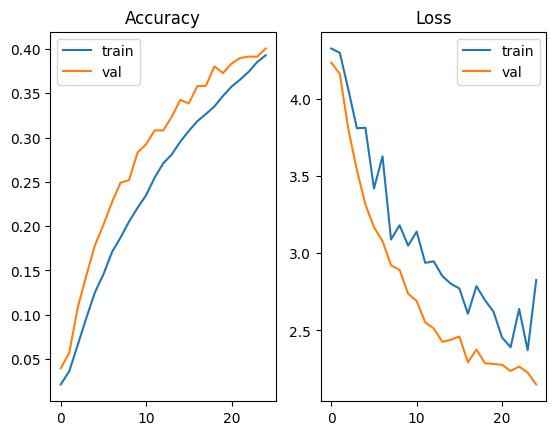

In [60]:
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 25), data["train acc"], label="train")
plt.plot(np.arange(0, 25), data["val acc"], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 25), data["train loss"], label="train")
plt.plot(np.arange(0, 25), data["val loss"], label="val")
plt.title("Loss")
plt.legend()

plt.show()

In [61]:
print(metrics.classification_report(gt, pred))

              precision    recall  f1-score   support

           0       0.51      0.57      0.54        63
           1       0.35      0.40      0.38        55
           2       0.31      0.40      0.35        62
           3       0.23      0.15      0.18        68
           4       0.25      0.18      0.21        55
           5       0.22      0.27      0.24        59
           6       0.49      0.52      0.50        67
           7       0.38      0.50      0.43        66
           8       0.33      0.27      0.30        62
           9       0.66      0.26      0.38        72
          10       0.21      0.15      0.18        59
          11       0.33      0.33      0.33        57
          12       0.35      0.37      0.36        62
          13       0.35      0.32      0.34        62
          14       0.39      0.26      0.31        58
          15       0.39      0.29      0.33        69
          16       0.54      0.32      0.40        47
          17       0.67    

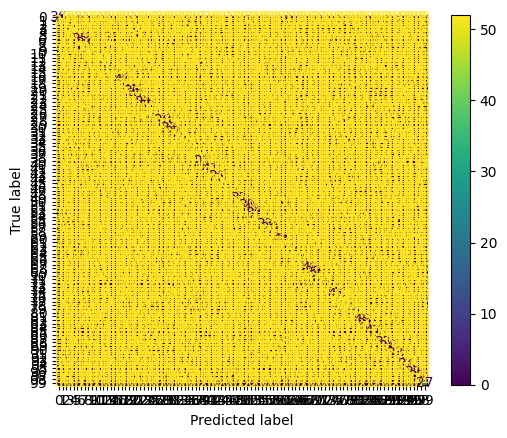

In [62]:
cm = metrics.confusion_matrix(gt, pred)
cmd = metrics.ConfusionMatrixDisplay(cm)
cmd.plot()